# 04. フーリエ変換 — 非周期関数を周波数に分ける

**学習目標**: 周期 $\to\infty$ の極限としてフーリエ変換を理解し、ガウス関数・矩形関数の
変換を計算して、**時間幅と周波数幅のトレードオフ(不確定性)** を体感する。

## Big Picture / Definition

周期を無限に伸ばすと、離散だった倍音が **連続スペクトル** になります。

$$ \hat f(\xi) = \int_{-\infty}^{\infty} f(x)\,e^{-2\pi i x\xi}\,dx, \qquad
   f(x) = \int_{-\infty}^{\infty} \hat f(\xi)\,e^{2\pi i x\xi}\,d\xi. $$

エネルギーは保存します(**Plancherel**): $\int|f|^2dx=\int|\hat f|^2d\xi$。

## Intuition

- 周期関数 → 線スペクトル(とびとびの周波数)
- 非周期(局在)関数 → 連続スペクトル(周波数が連続に分布)
- 時間で局在するほど、周波数では広がる(その逆も)= **不確定性**

In [1]:
# Shared setup: make fourier_book importable, fix seeds, inline rendering.
%matplotlib inline
import sys
from pathlib import Path

try:
    import fourier_book  # noqa: F401
except ModuleNotFoundError:
    for _base in (Path.cwd(), *Path.cwd().parents):
        if (_base / "src" / "fourier_book").is_dir():
            sys.path.insert(0, str(_base / "src"))
            break

import matplotlib.pyplot as plt
import numpy as np

from fourier_book import datasets, filters, plotting, signals, spectral, transforms, widgets

np.set_printoptions(precision=3, suppress=True)

In [2]:
# Numerical continuous Fourier transform on a fine, centered grid.
def cont_ft(x, f):
    dt = x[1] - x[0]
    n = len(x)
    spec = np.fft.fftshift(np.fft.fft(np.fft.ifftshift(f))) * dt
    xi = np.fft.fftshift(np.fft.fftfreq(n, d=dt))
    return xi, spec

x = np.linspace(-8, 8, 4096)

## Visualization 1 — ガウス関数のフーリエ変換はガウス関数

$e^{-\pi x^2}$ はこの変換のもとで **自分自身に移る**(自己双対)、という美しい例です。

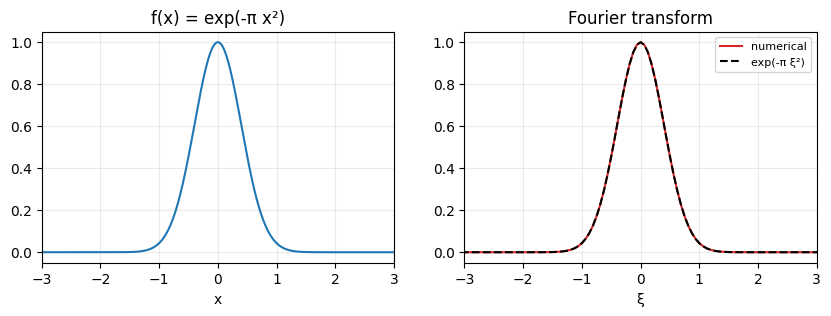

In [3]:
# The Gaussian exp(-π x²) is its own Fourier transform.
f = np.exp(-np.pi * x**2)
xi, F = cont_ft(x, f)

fig, ax = plt.subplots(1, 2, figsize=(10, 3))
ax[0].plot(x, f, color="#1f77b4"); ax[0].set_xlim(-3, 3)
ax[0].set_title("f(x) = exp(-π x²)"); ax[0].set_xlabel("x"); ax[0].grid(alpha=.25)
ax[1].plot(xi, F.real, color="#d62728", label="numerical")
ax[1].plot(xi, np.exp(-np.pi * xi**2), "k--", label="exp(-π ξ²)")
ax[1].set_xlim(-3, 3); ax[1].set_title("Fourier transform"); ax[1].set_xlabel("ξ")
ax[1].legend(fontsize=8); ax[1].grid(alpha=.25)
plt.show()

## Visualization 2 — 矩形関数 → sinc

幅 1 の矩形パルスの変換は $\operatorname{sinc}(\xi)=\dfrac{\sin\pi\xi}{\pi\xi}$。
時間で鋭く切ると、周波数では広く尾を引きます(06 章のスペクトル漏れと同根)。

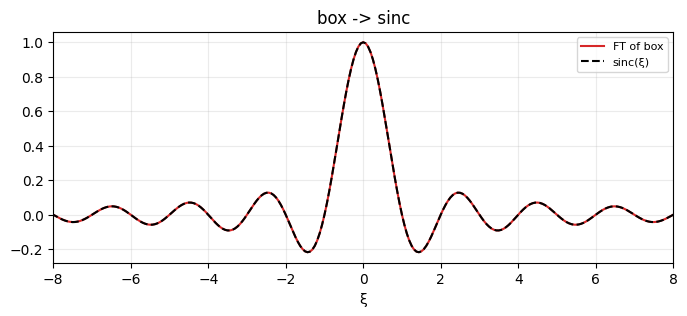

In [4]:
# A box becomes a sinc — sharp edges in time mean wide spread in frequency.
box = (np.abs(x) <= 0.5).astype(float)
xi, B = cont_ft(x, box)
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(xi, B.real, color="#d62728", label="FT of box")
ax.plot(xi, np.sinc(xi), "k--", label="sinc(ξ)")
ax.set_xlim(-8, 8); ax.set_title("box -> sinc"); ax.set_xlabel("ξ")
ax.legend(fontsize=8); ax.grid(alpha=.25)
plt.show()

## Failure Mode / Invariant — 不確定性原理

時間幅 $\Delta x$ と周波数幅 $\Delta\xi$ の積には下限があり、両方同時に小さくできません。

$$ \Delta x \cdot \Delta\xi \ \ge \ \frac{1}{4\pi}. $$

下で、ガウスの幅 $\sigma$ を変えると周波数側の幅が逆に変わることを見ます。

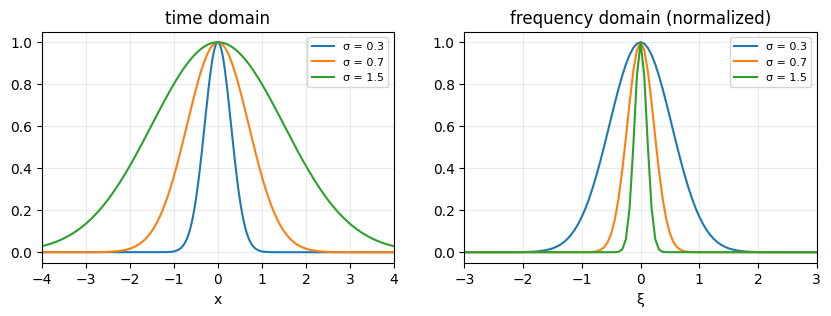

In [5]:
# Narrow in time <-> wide in frequency: the uncertainty trade-off.
fig, ax = plt.subplots(1, 2, figsize=(10, 3))
for sigma in [0.3, 0.7, 1.5]:
    g = np.exp(-x**2 / (2 * sigma**2))
    xi, G = cont_ft(x, g)
    ax[0].plot(x, g, label=f"σ = {sigma}")
    ax[1].plot(xi, np.abs(G) / np.abs(G).max(), label=f"σ = {sigma}")
ax[0].set_xlim(-4, 4); ax[0].set_title("time domain"); ax[0].set_xlabel("x"); ax[0].legend(fontsize=8)
ax[1].set_xlim(-3, 3); ax[1].set_title("frequency domain (normalized)"); ax[1].set_xlabel("ξ")
ax[1].legend(fontsize=8)
for a in ax:
    a.grid(alpha=.25)
plt.show()

## Application & TODO

応用: 分光・回折(空間版フーリエ変換)、量子力学(位置と運動量の不確定性)、
通信(帯域と時間長)。本書では 06 章で離散版(DFT)、05 章で畳み込み定理へ接続します。

```{admonition} TODO(発展として追記予定)
:class: tip
- Plancherel の数値検証(時間と周波数のエネルギー一致)
- 微分・平行移動・スケーリングの変換性質(表)
- デルタ関数と定数関数の変換(超関数、05 章と接続)
- 解析的フーリエ変換を SymPy で導出(`sympy.fourier_transform`)
```